In [25]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Set the actual file paths**

In [26]:
BASELINE_DIR = "/content/drive/MyDrive/HiCForecast_Baseline"
EXP1B_DIR    = "/content/drive/MyDrive/HicForecast_Project_experiment_1B"
EXP2A_DIR    = "/content/drive/MyDrive/HiCForecast_Project_experiment_2A"
EXP2B_DIR    = "/content/drive/MyDrive/HicForecast_Project_experiment_2B"
SAVE_DIR     = "/content/drive/MyDrive/HiCForecast_Project_experiment_3B"

os.makedirs(SAVE_DIR, exist_ok=True)

GT_PATH = f"{BASELINE_DIR}/HiCForecast/example_data/processed/data_gt_chr19_64.npy"
BASELINE_PATH = f"{BASELINE_DIR}/HiCForecast/HiCForecast_prediction.npy"
ENSEMBLE_MEAN_PATH = f"{EXP1B_DIR}/pred_ensemble_mean.npy"
GRAPH_DIFF_PATH = f"{EXP2A_DIR}/pred_graphdiff.npy"
REFINED_2B_PATH = f"{EXP2B_DIR}/pred_refined_2B.npy"

gt = np.load(GT_PATH).astype(np.float32)
baseline_pred = np.load(BASELINE_PATH).astype(np.float32)
ensemble_mean = np.load(ENSEMBLE_MEAN_PATH).astype(np.float32)
graph_diff = np.load(GRAPH_DIFF_PATH).astype(np.float32)
refined_2b = np.load(REFINED_2B_PATH).astype(np.float32)

print("GT shape           :", gt.shape)
print("Baseline shape     :", baseline_pred.shape)
print("Ensemble mean shape:", ensemble_mean.shape)
print("Graph diffusion    :", graph_diff.shape)
print("Refined 2B shape   :", refined_2b.shape)

GT shape           : (6, 1534, 1534)
Baseline shape     : (3, 1534, 1534)
Ensemble mean shape: (3, 1534, 1534)
Graph diffusion    : (3, 1534, 1534)
Refined 2B shape   : (3, 1534, 1534)


# **Apply fixed GT mapping**

In [28]:
fixed = [2, 5, 5]

def get_matched_gt(gt, fixed):
    return [gt[t] for t in fixed]

matched_gt = get_matched_gt(gt, fixed)
print("Using GT mapping:", fixed)

Using GT mapping: [2, 5, 5]


In [29]:
def insulation_vector_torch(mat: torch.Tensor, w: int = 4, eps: float = 1e-6):
    """
    3A-style insulation proxy:
    - ReLU on matrix
    - block SUM
    - log(v + eps)
    """
    if mat.dim() == 4:
        mat = mat[:, 0]   # (B,N,N)

    B, N, _ = mat.shape
    mat = torch.relu(mat)

    vals = []
    for i in range(w, N - w):
        block = mat[:, i-w:i, i:i+w]   # (B,w,w)
        vals.append(block.sum(dim=(1,2)))
    v = torch.stack(vals, dim=1)       # (B, N-2w)
    v = torch.log(v + eps)
    return v

def tad_insulation_loss_3A(pred: torch.Tensor, gt: torch.Tensor, w: int = 4):
    p = insulation_vector_torch(pred, w=w)
    g = insulation_vector_torch(gt, w=w)

    p = (p - p.mean(dim=1, keepdim=True)) / (p.std(dim=1, keepdim=True) + 1e-6)
    g = (g - g.mean(dim=1, keepdim=True)) / (g.std(dim=1, keepdim=True) + 1e-6)
    return F.l1_loss(p, g)

def peak_weighted_l1_3A(pred: torch.Tensor, gt: torch.Tensor,
                        gamma: float = 2.0, clamp_max: float = 10.0, eps: float = 1e-6):
    pred2 = pred[:, 0] if pred.dim() == 4 else pred
    gt2   = gt[:, 0] if gt.dim() == 4 else gt

    gt_mean = gt2.mean(dim=(1,2), keepdim=True)
    w = (gt2 / (gt_mean + eps)).clamp(min=0.0)
    w = torch.pow(w, gamma).clamp(max=clamp_max)

    return (w * (pred2 - gt2).abs()).mean()

# **Evaluate all four methods with the same 3A metrics**

In [30]:
def eval_structure_3A_style(pred_maps, gt, fixed, tag):
    rows = []
    for i in range(3):
        t = fixed[i]

        pred_t = torch.from_numpy(pred_maps[i:i+1]).unsqueeze(1)  # (1,1,N,N)
        gt_t   = torch.from_numpy(gt[t:t+1]).unsqueeze(1)

        ltad = float(tad_insulation_loss_3A(pred_t, gt_t, w=4))
        lpk  = float(peak_weighted_l1_3A(pred_t, gt_t, gamma=2.0))

        rows.append({
            "model": tag,
            "pred_idx": i,
            "gt_idx": t,
            "tad_insulation_loss": ltad,
            "peak_weighted_l1": lpk
        })
    return rows

all_rows = []
all_rows += eval_structure_3A_style(baseline_pred, gt, fixed, "baseline")
all_rows += eval_structure_3A_style(ensemble_mean, gt, fixed, "ensemble_mean")
all_rows += eval_structure_3A_style(graph_diff, gt, fixed, "graph_diffusion")
all_rows += eval_structure_3A_style(refined_2b, gt, fixed, "refined_2B")

df_final = pd.DataFrame(all_rows)
df_final

,model,pred_idx,gt_idx,tad_insulation_loss,peak_weighted_l1
0,baseline,0,2,0.040165,4.078927
1,baseline,1,5,0.051381,5.705303
2,baseline,2,5,0.049150,5.612514
3,ensemble_mean,0,2,0.031620,3.523050
4,ensemble_mean,1,5,0.050117,5.643742
5,ensemble_mean,2,5,0.048959,5.706868
6,graph_diffusion,0,2,0.050992,7.411793
7,graph_diffusion,1,5,0.063200,6.992376
8,graph_diffusion,2,5,0.063890,7.214933
9,refined_2B,0,2,0.296649,3.046461


# **Summary table**

In [31]:
summary_final = df_final.groupby("model")[["tad_insulation_loss", "peak_weighted_l1"]].mean().reset_index()
summary_final = summary_final.sort_values("tad_insulation_loss")
print("=== Final 3B summary using exact 3A metric definitions ===")
display(summary_final.round(6))

=== Final 3B summary using exact 3A metric definitions ===


,model,tad_insulation_loss,peak_weighted_l1
1,ensemble_mean,0.043565,4.957886
0,baseline,0.046899,5.132248
2,graph_diffusion,0.059361,7.206367
3,refined_2B,0.306925,4.749143


In [32]:
df_final.to_csv(f"{SAVE_DIR}/3B_final_all_structure_metrics.csv", index=False)
summary_final.to_csv(f"{SAVE_DIR}/3B_final_summary_structure_metrics.csv", index=False)

print("Saved:")
print(f"{SAVE_DIR}/3B_final_all_structure_metrics.csv")
print(f"{SAVE_DIR}/3B_final_summary_structure_metrics.csv")

Saved:
/content/drive/MyDrive/HiCForecast_Project_experiment_3B/3B_final_all_structure_metrics.csv
/content/drive/MyDrive/HiCForecast_Project_experiment_3B/3B_final_summary_structure_metrics.csv


# **Plot insulation profiles**

In [33]:
def plot_insulation_profiles_3A_style(pred_idx=0):
    gt_idx = fixed[pred_idx]

    gt_mat = torch.from_numpy(gt[gt_idx:gt_idx+1]).unsqueeze(1)
    pred_baseline = torch.from_numpy(baseline_pred[pred_idx:pred_idx+1]).unsqueeze(1)
    pred_ens = torch.from_numpy(ensemble_mean[pred_idx:pred_idx+1]).unsqueeze(1)
    pred_graph = torch.from_numpy(graph_diff[pred_idx:pred_idx+1]).unsqueeze(1)
    pred_refined = torch.from_numpy(refined_2b[pred_idx:pred_idx+1]).unsqueeze(1)

    g = insulation_vector_torch(gt_mat, w=4).squeeze(0).numpy()
    b = insulation_vector_torch(pred_baseline, w=4).squeeze(0).numpy()
    e = insulation_vector_torch(pred_ens, w=4).squeeze(0).numpy()
    d = insulation_vector_torch(pred_graph, w=4).squeeze(0).numpy()
    r = insulation_vector_torch(pred_refined, w=4).squeeze(0).numpy()

    plt.figure(figsize=(10,4))
    plt.plot(g, label="GT")
    plt.plot(b, label="Baseline")
    plt.plot(e, label="Ensemble Mean")
    plt.plot(d, label="Graph Diffusion")
    plt.plot(r, label="Refined 2B")
    plt.title(f"Insulation profile (pred_idx={pred_idx}, matched gt_idx={gt_idx})")
    plt.legend()
    plt.tight_layout()

    fig_path = f"{SAVE_DIR}/3B_final_insulation_pred{pred_idx}_gt{gt_idx}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("Saved:", fig_path)

# **Plot all three horizons**

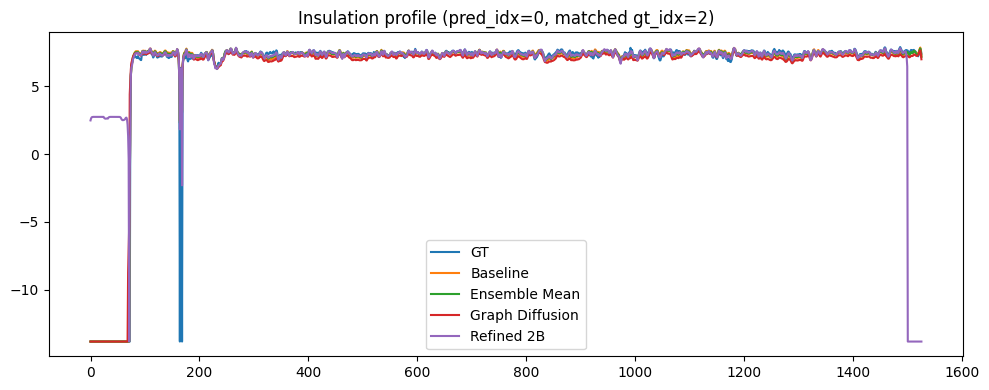

Saved: /content/drive/MyDrive/HiCForecast_Project_experiment_3B/3B_final_insulation_pred0_gt2.png


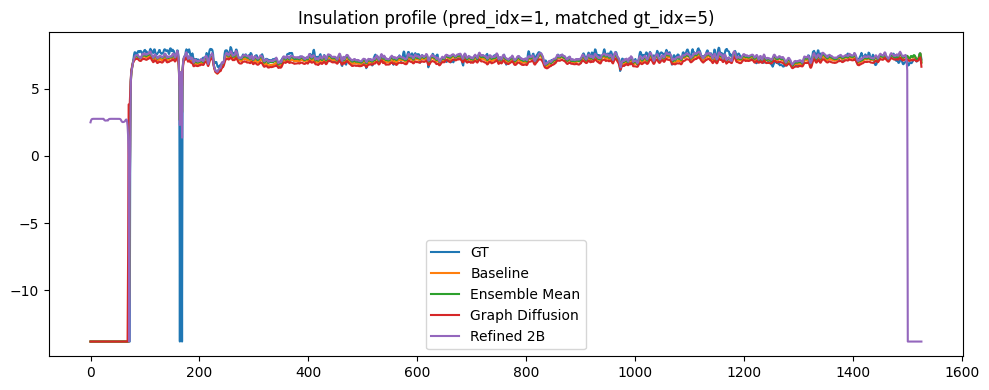

Saved: /content/drive/MyDrive/HiCForecast_Project_experiment_3B/3B_final_insulation_pred1_gt5.png


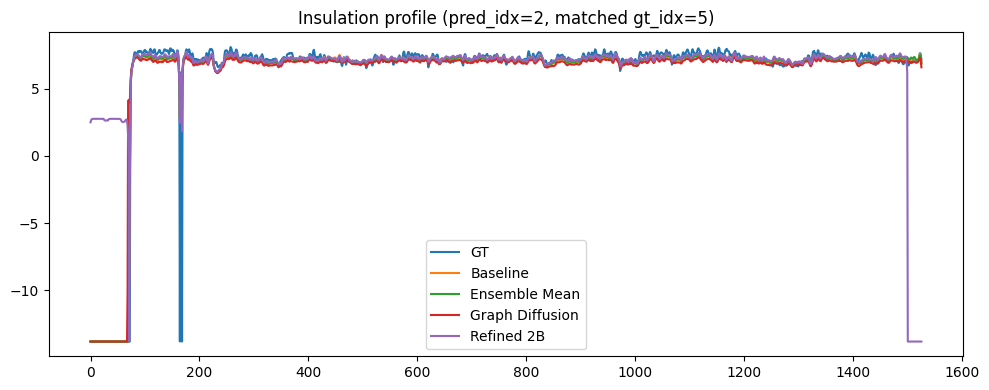

Saved: /content/drive/MyDrive/HiCForecast_Project_experiment_3B/3B_final_insulation_pred2_gt5.png


In [34]:
plot_insulation_profiles_3A_style(pred_idx=0)
plot_insulation_profiles_3A_style(pred_idx=1)
plot_insulation_profiles_3A_style(pred_idx=2)